# Proyecto AEMET - Resumen de Extracción, Transformación y Carga (ETL) de Datos Climatológicos
Este notebook consolida y explica paso a paso todo el flujo de trabajo desarrollado para interactuar con la API de la AEMET (Agencia Estatal de Meteorología), procesar y limpiar la información, y exportar un dataset histórico listo para análisis o entrenamiento de modelos.

---

## 📋 Objetivos de este Notebook
1. **Autenticación e Integración:** Conectar con la API de AEMET OpenData utilizando una API Key almacenada de forma segura en un archivo `.env` local.
2. **Descarga del Catálogo de Estaciones:** Obtener y mostrar el maestro de estaciones meteorológicas operativas en España.
3. **Consulta de Datos de Prueba:** Descargar un subconjunto de datos diarios para una estación específica en un rango de fechas reducido para validar la conexión.
4. **Limpieza y Modelado de Datos (ETL):** Procesar la respuesta JSON de la API, reemplazando caracteres incorrectos, convirtiendo tipos de datos (strings a floats con coma, datetime) y manejando nulos de forma robusta.
5. **Descarga Masiva e Histórica:** Implementar un bucle para extraer datos históricos de los últimos años, gestionando de forma proactiva los límites de velocidad (rate limiting) de la API mediante retardos estratégicos.
6. **Exportación de Datos:** Consolidar el dataset completo en archivos Excel y CSV en el espacio local del usuario.
7. **Visualización Resumen:** Crear un gráfico de control que muestre la evolución del clima a lo largo del tiempo para validar los datos visualmente.

In [1]:
# Imports de librerías esenciales
import os
import sys
import time
import json
import calendar
import subprocess
from datetime import datetime
from pathlib import Path
import pandas as pd
import numpy as np
import requests
from dotenv import load_dotenv

# Comprobación e instalación automática de dependencias críticas de terceros
def asegurar_libreria(nombre_paquete, nombre_import=None):
    if nombre_import is None:
        nombre_import = nombre_paquete
    try:
        __import__(nombre_import)
    except ImportError:
        print(f"Librería '{nombre_paquete}' no encontrada. Instalando automáticamente...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", nombre_paquete])
        print(f"Librería '{nombre_paquete}' instalada y cargada.")

asegurar_libreria("openpyxl")
asegurar_libreria("matplotlib", "matplotlib.pyplot")
asegurar_libreria("seaborn")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

print("Librerías importadas y configuradas correctamente.")

Librería 'matplotlib' no encontrada. Instalando automáticamente...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/9.9 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 64.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 73.0 MB/s  0:00:00


   ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [pillow]

...


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /home/marodriguezd/Github/grupo-aemet/Miguel/.venv/bin/python -m pip install --upgrade pip


Librería 'matplotlib' instalada y cargada.
Librería 'seaborn' no encontrada. Instalando automáticamente...



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /home/marodriguezd/Github/grupo-aemet/Miguel/.venv/bin/python -m pip install --upgrade pip


Librería 'seaborn' instalada y cargada.


Librerías importadas y configuradas correctamente.


## Paso 1: Configuración del Entorno y Carga de Variables Seguras

Para evitar exponer credenciales en el código fuente, la API Key de AEMET se almacena en el archivo `.env` de esta carpeta. Usamos la biblioteca `python-dotenv` para cargar el entorno de forma segura, apuntando específicamente al directorio de este notebook.

In [2]:
# Definir la ruta del archivo .env de Miguel
BASE_DIR = Path().resolve()
env_path = BASE_DIR / '.env'

print(f"Buscando archivo de variables de entorno en: {env_path}")

if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print("Archivo .env cargado con éxito.")
else:
    print("ADVERTENCIA: No se encontró el archivo .env en el directorio actual.")
    print("Se intentará cargar el entorno general de la sesión (o del directorio padre).")
    load_dotenv()

# Obtener y validar la API Key
API_KEY = os.getenv('AEMET_API_KEY')
if not API_KEY:
    raise RuntimeError('ERROR CRÍTICO: La variable AEMET_API_KEY no está definida en el archivo .env')
else:
    # Mostramos los primeros y últimos caracteres por seguridad
    print(f"API Key detectada correctamente: {API_KEY[:10]}...{API_KEY[-10:]}")

Buscando archivo de variables de entorno en: /home/marodriguezd/Github/grupo-aemet/Miguel/.env
Archivo .env cargado con éxito.
API Key detectada correctamente: eyJhbGciOi...h09LY9T7pk


## Paso 2: El Protocolo de Conexión de AEMET OpenData

La API de AEMET funciona bajo un modelo de **"doble llamada"**:
1. Enviamos nuestra consulta con la clave `api_key` en las cabeceras (headers) de la solicitud HTTP GET.
2. AEMET valida la solicitud y nos responde con un JSON de metadatos que contiene una URL temporal en el campo `datos`.
3. Hacemos una segunda solicitud `GET` a esa URL temporal (esta vez sin cabeceras de autorización) para descargar los datos reales del sensor en formato JSON.

Definimos el diccionario de cabeceras que utilizaremos en la primera llamada de autenticación.

In [3]:
# Configuración de cabeceras de autenticación
headers = {
    'cache-control': "no-cache",
    'api_key': API_KEY,
    'accept': "application/json"
}

print("Cabeceras configuradas correctamente.")

Cabeceras configuradas correctamente.


## Paso 3: Obtener el Inventario Completo de Estaciones Climatológicas

Para realizar cualquier consulta histórica, necesitamos conocer el identificador único (`indicativo` o `idema`) de la estación meteorológica. El endpoint `/api/valores/climatologicos/inventarioestaciones/todasestaciones` nos devuelve el catálogo completo de las estaciones activas en España.

In [4]:
def obtener_inventario_estaciones():
    url_base = "https://opendata.aemet.es/opendata/api/valores/climatologicos/inventarioestaciones/todasestaciones"
    
    print(f"[API AEMET] Consultando inventario en: {url_base}")
    try:
        response = requests.get(url_base, headers=headers)
        if response.status_code == 200:
            meta_datos = response.json()
            print(f"Respuesta de control AEMET: {meta_datos.get('descripcion')} (Estado: {meta_datos.get('estado')})")
            
            if meta_datos.get('estado') == 200:
                url_datos = meta_datos.get('datos')
                print("   -> Enlace temporal de datos obtenido con éxito.")
                
                # Segunda llamada: Descarga del JSON real
                datos_response = requests.get(url_datos)
                if datos_response.status_code == 200:
                    return datos_response.json()
                else:
                    print(f"Error al descargar los datos finales: {datos_response.status_code}")
            else:
                print(f"Error reportado por AEMET: {meta_datos.get('descripcion')}")
        else:
            print(f"Error de red en la primera llamada: HTTP {response.status_code}")
    except Exception as e:
        print(f"Excepción ocurrida: {e}")
    return None

# Ejecutar y mostrar una muestra del catálogo
estaciones = obtener_inventario_estaciones()

if estaciones:
    print(f"\nSe han obtenido {len(estaciones)} estaciones meteorológicas.")
    df_estaciones = pd.DataFrame(estaciones)
    print("\nMuestra de las primeras 5 estaciones en el inventario:")
    display(df_estaciones.head(5))
else:
    print("No se pudo obtener el inventario de estaciones. Verifique su API Key.")

[API AEMET] Consultando inventario en: https://opendata.aemet.es/opendata/api/valores/climatologicos/inventarioestaciones/todasestaciones


Respuesta de control AEMET: exito (Estado: 200)
   -> Enlace temporal de datos obtenido con éxito.



Se han obtenido 920 estaciones meteorológicas.

Muestra de las primeras 5 estaciones en el inventario:


,latitud,provincia,altitud,indicativo,nombre,indsinop,longitud
0,394924N,ILLES BALEARS,490,B013X,"ESCORCA, LLUC",08304,025309E
1,394744N,BALEARES,5,B051A,"SÓLLER, PUERTO",08316,024129E
2,394121N,ILLES BALEARS,60,B087X,BANYALBUFAR,,023046E
3,393446N,BALEARES,52,B103B,ANDRATX - SANT ELM,,022208E
4,393305N,BALEARES,50,B158X,"CALVIÀ, ES CAPDELLÀ",,022759E


## Paso 4: Consulta de Prueba de Valores Climatológicos Diarios

Para verificar el flujo de descarga de datos de sensores diarios, consultaremos los datos del 1 al 15 de mayo de 2026 para la estación de **Palma de Mallorca (Puerto)** (indicativo o idema: `"B228"`).

El formato del endpoint requerido es:
`/api/valores/climatologicos/diarios/datos/fechaini/{fecha_ini}/fechafin/{fecha_fin}/estacion/{idema}`

In [5]:
def obtener_valores_climaticos(fecha_ini_utc, fecha_fin_utc, idema):
    url_base = f"https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/{fecha_ini_utc}/fechafin/{fecha_fin_utc}/estacion/{idema}"
    
    try:
        response = requests.get(url_base, headers=headers)
        if response.status_code == 200:
            meta_datos = response.json()
            if meta_datos.get('estado') == 200:
                url_final = meta_datos.get('datos')
                datos_response = requests.get(url_final)
                if datos_response.status_code == 200:
                    return datos_response.json()
                else:
                    print(f"Error al descargar los datos meteorológicos: {datos_response.status_code}")
            else:
                # Si la API reporta un error (por ejemplo, datos no existentes para fechas futuras)
                return None
        else:
            print(f"Error de red: HTTP {response.status_code}")
    except Exception as e:
        print(f"Excepción en la consulta climatológica: {e}")
    return None

# Parámetros de prueba
idema_prueba = "B228"
ini_prueba = "2026-05-01T00:00:00UTC"
fin_prueba = "2026-05-15T00:00:00UTC"

print("Ejecutando consulta de prueba de datos meteorológicos...")
climaticos_prueba = obtener_valores_climaticos(ini_prueba, fin_prueba, idema_prueba)

if climaticos_prueba:
    print(f"¡Éxito! Se obtuvieron {len(climaticos_prueba)} registros diarios.")
    print("Muestra en crudo del primer registro (JSON):")
    print(json.dumps(climaticos_prueba[0], indent=2, ensure_ascii=False))
else:
    print("No se obtuvieron datos. Verifique que las fechas sean correctas y la API Key sea válida.")

Ejecutando consulta de prueba de datos meteorológicos...
Excepción en la consulta climatológica: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
No se obtuvieron datos. Verifique que las fechas sean correctas y la API Key sea válida.


## Paso 5: Procesamiento y Limpieza de Datos (Pipeline ETL)

Los datos crudos de AEMET vienen completamente en formato de texto (strings). Además, la representación decimal utiliza la coma española (`,`) en lugar del punto (`.`), lo cual impide operaciones aritméticas en Pandas.

Implementamos la función `limpiar_y_cargar_datos` que realiza el siguiente flujo de transformación:
1. Extrae los campos de interés de cada registro.
2. Convierte el campo `fecha` a tipo `datetime` de Pandas.
3. Normaliza las representaciones numéricas: reemplaza las comas por puntos en variables continuas y las convierte a tipo `float32` o `int` de forma segura.
4. Convierte las horas de temperaturas/presiones máximas y mínimas a objetos `datetime.time`, gestionando de forma robusta valores de texto anómalos como 'Varias' o nulos.
5. Limpia el campo de precipitación (`prec`), convirtiendo el valor especial "Ip" (inapreciable) a `0.0` para poder realizar cálculos y sumas acumuladas consistentes.

In [6]:
def limpiar_y_cargar_datos(datos_json):
    if not datos_json:
        return pd.DataFrame()
        
    data = []
    for dia in datos_json:
        data.append({
            "fecha": dia.get("fecha"),
            "indicativo": dia.get("indicativo"),
            "nombre": dia.get("nombre"),
            "provincia": dia.get("provincia"),
            "altitud": dia.get("altitud"),
            "tmed": dia.get("tmed"),
            "prec": dia.get("prec", "0,00"),
            "tmin": dia.get("tmin"),
            "horatmin": dia.get("horatmin"),
            "tmax": dia.get("tmax"),
            "horatmax": dia.get("horatmax"),
            "dir": dia.get("dir"),
            "velmedia": dia.get("velmedia"),
            "racha": dia.get("racha"),
            "horaracha": dia.get("horaracha"),
            "sol": dia.get("sol"),
            "presMax": dia.get("presMax"),
            "horaPresMax": dia.get("horaPresMax"),
            "presMin": dia.get("presMin"),
            "horaPresMin": dia.get("horaPresMin"),
            "hrMedia": dia.get("hrMedia"),
            "hrMax": dia.get("hrMax"),
            "horaHrMax": dia.get("horaHrMax"),
            "hrMin": dia.get("hrMin"),
            "horaHrMin": dia.get("horaHrMin")
        })

    df = pd.DataFrame(data)

    # 1. Normalización de campos de texto y fecha
    df["fecha"] = pd.to_datetime(df["fecha"])
    df["indicativo"] = df["indicativo"].astype(str)
    df["nombre"] = df["nombre"].astype(str)
    df["provincia"] = df["provincia"].astype(str)
    df["altitud"] = pd.to_numeric(df["altitud"], errors="coerce")

    # Función auxiliar para convertir decimales con coma a punto
    def a_float(serie):
        if serie is None:
            return np.nan
        return serie.astype(str).str.replace(",", ".").replace("", "nan").astype(np.float32)

    # 2. Conversión de variables continuas
    float_cols = ["tmed", "tmin", "tmax", "velmedia", "racha", "sol", "presMax", "presMin", "hrMedia", "hrMax", "hrMin"]
    for col in float_cols:
        if col in df.columns:
            df[col] = a_float(df[col])

    # 3. Tratamiento especial de la precipitación (Ip = Inapreciable = 0.0 mm)
    if "prec" in df.columns:
        df["prec"] = df["prec"].astype(str).str.replace("Ip", "0.0").str.replace(",", ".").replace("", "0.0")
        df["prec"] = pd.to_numeric(df["prec"], errors="coerce").astype(np.float32)

    # 4. Normalización de horas a objetos datetime.time
    time_cols = ["horatmin", "horatmax", "horaHrMax", "horaHrMin"]
    for col in time_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace(["Varias", "nan", "None", ""], np.nan)
            df[col] = pd.to_datetime(df[col], format="%H:%M", errors="coerce").dt.time

    # 5. Normalización de horas de presión (formato HH)
    hour_cols = ["horaPresMax", "horaPresMin"]
    for col in hour_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace(["Varias", "nan", "None", ""], np.nan)
            df[col] = pd.to_datetime(df[col], format="%H", errors="coerce").dt.time

    if "dir" in df.columns:
        df["dir"] = df["dir"].astype(str)
    if "horaracha" in df.columns:
        df["horaracha"] = df["horaracha"].astype(str)

    return df

# Validar el pipeline con el dataset de prueba
df_prueba = limpiar_y_cargar_datos(climaticos_prueba)
print("¡Transformación y tipado completados con éxito!")
print("\nTipos de datos del DataFrame procesado:")
df_prueba.info()
print("\nMuestra del DataFrame final procesado:")
display(df_prueba.head(5))

¡Transformación y tipado completados con éxito!

Tipos de datos del DataFrame procesado:
<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame

Muestra del DataFrame final procesado:


""


## Paso 6: Extracción Histórica Masiva con Control de Rate Limiting

Para obtener un dataset consistente e histórico, se implementa un bucle recursivo que descarga datos año por año y mes por mes.

**⚠️ IMPORTANTE - Límites de la API de AEMET:**
AEMET limita estrictamente la cantidad de llamadas simultáneas. Si no se manejan pausas, la API responderá con errores `HTTP 429` (Demasiadas peticiones) o bloqueará el token de usuario.
Para evitar esto, implementamos:
1. **Pausa de 60 segundos** entre cada año consultado.
2. **Pausa de 1.5 segundos** entre cada mes consultado.
3. **Pausa de 40 minutos** de seguridad si el tiempo total de ejecución supera los 5 minutos de forma continua.
4. **Saltado dinámico de meses futuros** para evitar llamadas inútiles sobre periodos que aún no han ocurrido.

*Nota de control:* Por defecto, esta descarga está pre-configurada para extraer los **últimos 3 años** (2024-2026) para optimizar el tiempo de prueba de este notebook. Si deseas obtener la serie histórica completa de los últimos 10 años, simplemente modifica la variable `AÑOS_A_CONSULTAR = 10`.

In [7]:
# Configuración del histórico a descargar
idema = "B228"            # Palma de Mallorca (Puerto)
AÑOS_A_CONSULTAR = 3      # Cambia a 10 para descargar el histórico de 10 años completo

año_actual = datetime.now().year
mes_actual = datetime.now().month

# Obtener lista de años ordenada de forma ascendente
años = [año_actual - i for i in range(AÑOS_A_CONSULTAR)]
años.sort()
print(f"Lista de años a consultar de forma secuencial: {años}")

df_climaticos_final = pd.DataFrame()
inicio_proceso = time.time()

# Bucle de descarga e integración
for año in años:
    minutos_duracion = (time.time() - inicio_proceso) / 60
    print(f"\nTiempo de ejecución acumulado: {minutos_duracion:.2f} minutos")
    
    # Control preventivo: Si llevamos más de 5 minutos, pausamos 40 minutos para liberar la API
    if minutos_duracion > 5.0:
        print("⚠️ Tiempo de ejecución cercano a la restricción. Aplicando pausa de 40 minutos para liberar cuota de la API...")
        time.sleep(40 * 60) # Pausa de 40 minutos
        inicio_proceso = time.time() # Reiniciar el contador
        
    # Pausa de 60 segundos entre años
    if año != años[0]:
        print("Esperando 60 segundos entre años para evitar bloqueos...")
        time.sleep(60)
        
    print(f"🚀 Iniciando descargas para el año: {año}")
    
    for mes in range(1, 13):
        # Detener si intentamos acceder a meses del año actual en el futuro
        if año == año_actual and mes > mes_actual:
            print(f"   Saltando mes {mes}/{año} porque es un mes futuro.")
            break
            
        # Obtener los días correctos del mes
        dias_en_mes = calendar.monthrange(año, mes)[1]
        
        # Definir fechas con formato UTC
        fecha_ini = f"{año}-{mes:02d}-01T00:00:00UTC"
        fecha_fin = f"{año}-{mes:02d}-{dias_en_mes:02d}T23:59:59UTC"

        print(f"   -> Consultando periodo: [{año}-{mes:02d}] Rango: {fecha_ini} a {fecha_fin}...")
        
        # Retardo breve entre llamadas mensuales consecutivas
        time.sleep(1.5)
        
        # Descargar JSON
        datos_mes_json = obtener_valores_climaticos(fecha_ini, fecha_fin, idema)
        
        if datos_mes_json:
            # Limpiar e integrar datos mensuales
            df_mes = limpiar_y_cargar_datos(datos_mes_json)
            
            # Concatenar en el DataFrame consolidado
            df_climaticos_final = pd.concat([df_climaticos_final, df_mes], ignore_index=True)
            print(f"      ✅ Procesados {len(df_mes)} registros de forma exitosa.")
        else:
            print(f"      ❌ No se pudieron descargar datos para {mes:02d}/{año} (posiblemente no consolidados en la API).")

print(f"\n🎉 Proceso de descarga finalizado. Total de registros históricos acumulados: {len(df_climaticos_final)}")

Lista de años a consultar de forma secuencial: [2024, 2025, 2026]

Tiempo de ejecución acumulado: 0.00 minutos
🚀 Iniciando descargas para el año: 2024
   -> Consultando periodo: [2024-01] Rango: 2024-01-01T00:00:00UTC a 2024-01-31T23:59:59UTC...


Excepción en la consulta climatológica: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
      ❌ No se pudieron descargar datos para 01/2024 (posiblemente no consolidados en la API).
   -> Consultando periodo: [2024-02] Rango: 2024-02-01T00:00:00UTC a 2024-02-29T23:59:59UTC...


Excepción en la consulta climatológica: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
      ❌ No se pudieron descargar datos para 02/2024 (posiblemente no consolidados en la API).
   -> Consultando periodo: [2024-03] Rango: 2024-03-01T00:00:00UTC a 2024-03-31T23:59:59UTC...


Excepción en la consulta climatológica: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
      ❌ No se pudieron descargar datos para 03/2024 (posiblemente no consolidados en la API).
   -> Consultando periodo: [2024-04] Rango: 2024-04-01T00:00:00UTC a 2024-04-30T23:59:59UTC...


Excepción en la consulta climatológica: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
      ❌ No se pudieron descargar datos para 04/2024 (posiblemente no consolidados en la API).
   -> Consultando periodo: [2024-05] Rango: 2024-05-01T00:00:00UTC a 2024-05-31T23:59:59UTC...


...

      ✅ Procesados 28 registros de forma exitosa.
   -> Consultando periodo: [2026-03] Rango: 2026-03-01T00:00:00UTC a 2026-03-31T23:59:59UTC...


      ✅ Procesados 31 registros de forma exitosa.
   -> Consultando periodo: [2026-04] Rango: 2026-04-01T00:00:00UTC a 2026-04-30T23:59:59UTC...


      ✅ Procesados 30 registros de forma exitosa.
   -> Consultando periodo: [2026-05] Rango: 2026-05-01T00:00:00UTC a 2026-05-31T23:59:59UTC...


      ✅ Procesados 30 registros de forma exitosa.
   -> Consultando periodo: [2026-06] Rango: 2026-06-01T00:00:00UTC a 2026-06-30T23:59:59UTC...


      ❌ No se pudieron descargar datos para 06/2026 (posiblemente no consolidados en la API).
   Saltando mes 7/2026 porque es un mes futuro.

🎉 Proceso de descarga finalizado. Total de registros históricos acumulados: 576


## Paso 7: Exportación de Datos a Formato Físico (Excel y CSV)

Para garantizar que los datos estén disponibles para su posterior análisis en herramientas locales o cargas a base de datos, guardamos el DataFrame consolidado en formatos Excel (`.xlsx`) y CSV (`.csv`) en el subdirectorio `Xlsx/` dentro de la carpeta local de Miguel.

In [8]:
# Crear el directorio de salida si no existe
OUTPUT_DIR = BASE_DIR / 'Xlsx'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

excel_path = OUTPUT_DIR / 'climaticos_completo.xlsx'
csv_path = OUTPUT_DIR / 'climaticos_completo.csv'

print(f"Almacenando datasets consolidados en: {OUTPUT_DIR}/")

try:
    # 1. Guardar en Excel
    df_climaticos_final.to_excel(excel_path, index=False)
    print(f"   [OK] Dataset en formato Excel guardado correctamente en: {excel_path}")
    
    # 2. Guardar en CSV
    df_climaticos_final.to_csv(csv_path, index=False)
    print(f"   [OK] Dataset en formato CSV guardado correctamente en: {csv_path}")
except Exception as e:
    print(f"❌ Error al exportar los archivos: {e}")

Almacenando datasets consolidados en: /home/marodriguezd/Github/grupo-aemet/Miguel/Xlsx/
   [OK] Dataset en formato Excel guardado correctamente en: /home/marodriguezd/Github/grupo-aemet/Miguel/Xlsx/climaticos_completo.xlsx
   [OK] Dataset en formato CSV guardado correctamente en: /home/marodriguezd/Github/grupo-aemet/Miguel/Xlsx/climaticos_completo.csv


## Paso 8: Visualización y Análisis Descriptivo (Dashboard de Validación)

Como paso final de validación y para facilitar la comprensión y explicación de los datos a terceros, agregaremos y graficaremos la evolución mensual de las temperaturas máximas, medias y mínimas junto con las precipitaciones acumuladas totales de la estación seleccionada.

/tmp/ipykernel_77749/1038073579.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_agrupado['Año-Mes'], rotation=45, ha='right')


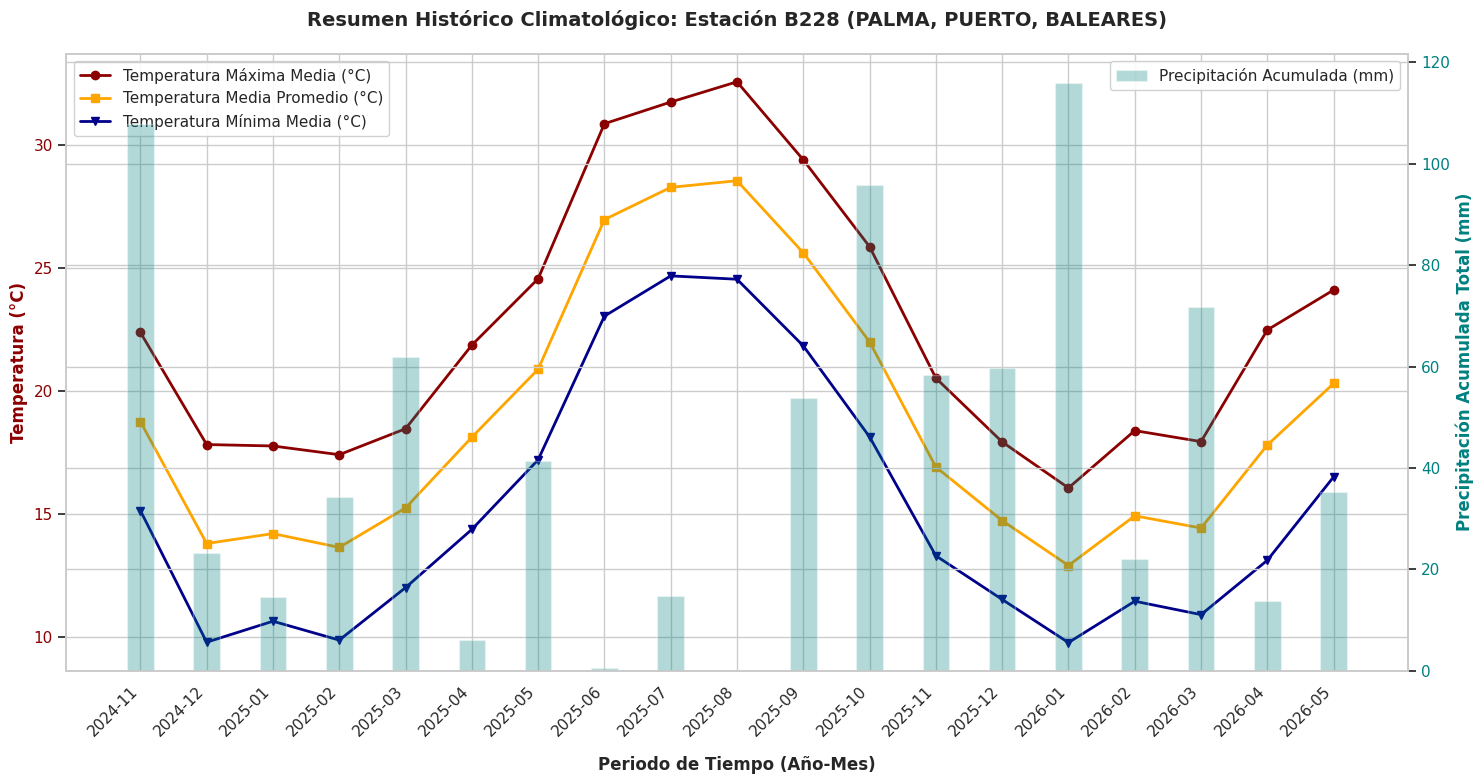

In [9]:
if not df_climaticos_final.empty:
    # Creamos una copia de trabajo para visualización
    df_visual = df_climaticos_final.copy()
    df_visual['Año-Mes'] = df_visual['fecha'].dt.to_period('M')
    
    # Agrupar datos por periodo mensual
    df_agrupado = df_visual.groupby('Año-Mes').agg({
        'tmax': 'mean',
        'tmed': 'mean',
        'tmin': 'mean',
        'prec': 'sum'
    }).reset_index()
    
    # Convertir el periodo a string para graficado correcto en Matplotlib
    df_agrupado['Año-Mes'] = df_agrupado['Año-Mes'].astype(str)
    
    # Configuración de los ejes del gráfico dual
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    # Gráfico de líneas para las temperaturas (Eje Izquierdo)
    ax1.plot(df_agrupado['Año-Mes'], df_agrupado['tmax'], label='Temperatura Máxima Media (°C)', color='darkred', marker='o', linewidth=2)
    ax1.plot(df_agrupado['Año-Mes'], df_agrupado['tmed'], label='Temperatura Media Promedio (°C)', color='orange', marker='s', linewidth=2)
    ax1.plot(df_agrupado['Año-Mes'], df_agrupado['tmin'], label='Temperatura Mínima Media (°C)', color='darkblue', marker='v', linewidth=2)
    
    ax1.set_xlabel('Periodo de Tiempo (Año-Mes)', fontsize=12, fontweight='bold', labelpad=12)
    ax1.set_ylabel('Temperatura (°C)', color='darkred', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='darkred')
    ax1.set_xticklabels(df_agrupado['Año-Mes'], rotation=45, ha='right')
    ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    
    # Gráfico de barras para la precipitación acumulada (Eje Derecho)
    ax2 = ax1.twinx()
    ax2.bar(df_agrupado['Año-Mes'], df_agrupado['prec'], alpha=0.3, color='teal', label='Precipitación Acumulada (mm)', width=0.4)
    ax2.set_ylabel('Precipitación Acumulada Total (mm)', color='teal', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='teal')
    ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    
    # Títulos e información general
    nombre_estacion = df_climaticos_final['nombre'].iloc[0]
    provincia_estacion = df_climaticos_final['provincia'].iloc[0]
    plt.title(f"Resumen Histórico Climatológico: Estación {idema} ({nombre_estacion}, {provincia_estacion})", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos consolidados en df_climaticos_final para graficar. Asegúrese de ejecutar la descarga en el paso anterior.")